# Core Concepts of Transformers

A Transformer is the design behind ChatGPT, Claude, BERT, Llama and almost every modern language model.
Think of it as a **reading room**: every word in a sentence gets to look at every other word at the same time
and decide which ones matter for understanding it — instead of reading left-to-right one word at a time like an RNN.

The architecture is made of a handful of interconnected pieces. Each piece has one job, and together they turn a
sequence of words into a **representation** (a list of numbers per word that captures its meaning *in context*),
which can then be used to make predictions.

How data flows through a Transformer (we build the pieces in exactly this order):
```
 "the cat sat"                       ← raw text
      ↓  tokenizer                   ← words → ID numbers        [12, 45, 92]
 1. Embeddings                       ← ID numbers → meaning vectors
 2. + Positional Encoding            ← stamp each vector with its seat number
      ↓
 ┌─ Transformer block (repeated N times) ───────────────┐
 │ 3–5. (Masked) Multi-Head Self-Attention              │  ← words look at each other
 │ 6.   Add & Norm                                      │  ← keep the original + steady the numbers
 │ 7.   Feed-Forward Network                            │  ← each word "thinks" on its own
 │ 6.   Add & Norm                                      │
 └──────────────────────────────────────────────────────┘
      ↓
 9. Linear layer + Softmax           ← scores → probabilities for every word in the vocabulary
      ↓
 "on"                                ← predicted next word
```

**Where this notebook fits:** this is the one-page map of all the pieces. For the deep dive (proving attention
matches PyTorch, why √d matters, a transformer that learns to sort) see `pytorch/phase8.ipynb`. To see the pieces
trained for real: `tinyGpt.ipynb` (decoder-only, writes Shakespeare) and `sentimentTransformer.ipynb`
(encoder-only BERT, reads movie reviews).

In [64]:
# ==========================================
# 0. SETUP
# ==========================================
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)   # Fix the dice rolls so every run prints the same numbers
np.set_printoptions(precision=3, suppress=True)   # Print numbers to 3 decimals, no scientific notation
torch.set_printoptions(precision=3, sci_mode=False)

## Part 1 — The Building Blocks

### 1. Embeddings — turning words into numbers

A neural network can only do maths on numbers, so first every word (token) is swapped for an ID from a fixed
**vocabulary** (the model's dictionary), and then each ID is swapped for a **vector** — a list of numbers that
describes the word, like GPS coordinates for its meaning.

`nn.Embedding` is simply a big lookup table: one row per word in the vocabulary. The rows start out random and are
**learned** during training, so words used in similar ways (*"cat"*, *"dog"*) drift close together.

In [65]:
# ==========================================
# 1. EMBEDDINGS (word ID → meaning vector)
# ==========================================
vocabulary_size = 10000      # How many different tokens the model knows
embedding_dimension = 128    # How many numbers describe each token (GPT-2 uses 768)

# Step A: The lookup table - 10,000 rows, each a 128-number vector (random until trained)
embedding_layer = nn.Embedding(vocabulary_size, embedding_dimension)



print("=== THE MODEL'S INTERNAL DICTIONARY MATRIX ===")
print("Shape of full weight matrix:", embedding_layer.weight.shape)
print(embedding_layer.weight.data)
print("=" * 50 + "\n")


# Step B: A batch of 2 sentences, each already turned into 4 token IDs by a tokenizer
# We add a batch dimension here -> shape: (batch_size=2, sequence_length=4)
input_tokens = torch.tensor([
    [12, 45, 92, 17],
    [31, 11, 76, 12]      # Note: token 12 appears in both sentences
])

# Step C: Look up the vector for every token
embedded_sentence = embedding_layer(input_tokens)


# Print the step-by-step structural results
print("=== FORWARD PASS TRACE ===")
print("1. Original Input Tensor:")
print(f"   Shape: {input_tokens.shape} -> (Batch Size, Sequence Length)")
print(f"   Values: {input_tokens.tolist()}\n")


print("2. Embedded Output Matrix:")
print(f"   Shape: {embedded_sentence.shape} -> (Batch Size, Sequence Length, Embedding Dim)")
print("   Values:")
print(embedded_sentence.data)
print("=" * 26)


# The same token always gets the same vector - no matter which sentence or position it's in
print("Token 12 gets the same vector in both sentences:", torch.equal(embedded_sentence[0, 0], embedded_sentence[1, 3]))

=== THE MODEL'S INTERNAL DICTIONARY MATRIX ===
Shape of full weight matrix: torch.Size([10000, 128])
tensor([[ 1.927,  1.487,  0.901,  ...,  0.340,  0.720,  0.411],
        [ 1.931,  1.012, -1.436,  ...,  0.566,  0.506,  0.222],
        [-0.685,  0.564, -1.507,  ...,  0.854, -0.490, -0.359],
        ...,
        [-0.058, -0.052, -0.871,  ..., -0.335, -0.043,  1.270],
        [ 0.852,  0.321,  0.985,  ..., -0.556,  0.215,  1.271],
        [-2.187, -0.133,  0.997,  ..., -0.851,  0.301, -0.808]])

=== FORWARD PASS TRACE ===
1. Original Input Tensor:
   Shape: torch.Size([2, 4]) -> (Batch Size, Sequence Length)
   Values: [[12, 45, 92, 17], [31, 11, 76, 12]]

2. Embedded Output Matrix:
   Shape: torch.Size([2, 4, 128]) -> (Batch Size, Sequence Length, Embedding Dim)
   Values:
tensor([[[-0.850, -0.699, -0.205,  ...,  0.382, -1.653, -0.381],
         [-1.039, -0.143,  1.130,  ..., -1.784, -1.239,  0.937],
         [ 0.132, -1.005,  0.125,  ..., -0.614, -1.303,  0.495],
         [-1.434, -0.

That last line is a problem in disguise: *"dog bites man"* and *"man bites dog"* give the model **exactly the same
three vectors**, just shuffled. Nothing yet says *where* each word sits. That's the job of the next piece.

### 2. Positional Encoding — giving every word a seat number

Self-attention (next section) compares every word with every other word, but the comparison **ignores order** —
to attention, a sentence is a bag of words. So before attention runs, we **add** a unique "position fingerprint"
to each word's vector: position 0 gets one pattern, position 1 another, and so on.

The original Transformer paper built these fingerprints out of sine and cosine waves of different speeds — like a
clock with many hands: the fast hands tell neighbouring positions apart, the slow hands tell far-apart positions
apart. Every position ends up with a unique combination.

=== 1. POSITIONAL ENCODING MATRIX ===
Positional encoding shape: torch.Size([1, 4, 128])
tensor([[ 0.000,  1.000,  0.000,  1.000,  0.000,  1.000,  0.000,  1.000],
        [ 0.841,  0.540,  0.762,  0.648,  0.682,  0.732,  0.605,  0.796],
        [ 0.909, -0.416,  0.987, -0.160,  0.997,  0.071,  0.963,  0.269],
        [ 0.141, -0.990,  0.517, -0.856,  0.778, -0.628,  0.930, -0.368]])
=== 2. FINAL INTEGRATED TRANSFORMER INPUT ===
Shape: Embeddings + positions   : torch.Size([2, 4, 128])
tensor([[[-0.850,  0.301, -0.205,  ...,  1.382, -1.653,  0.619],
         [-0.197,  0.397,  1.892,  ..., -0.784, -1.239,  1.937],
         [ 1.041, -1.421,  1.112,  ...,  0.386, -1.303,  1.495],
         [-1.292, -1.866,  0.527,  ...,  0.970,  1.272,  2.085]],

        [[ 0.308,  0.872,  0.037,  ...,  0.860,  0.942,  0.988],
         [ 1.112, -0.642, -0.272,  ...,  1.220,  0.325,  2.319],
         [ 0.622, -1.470, -0.610,  ...,  1.239,  0.740,  2.561],
         [-0.709, -1.689,  0.312,  ...,  1.382, -1.65

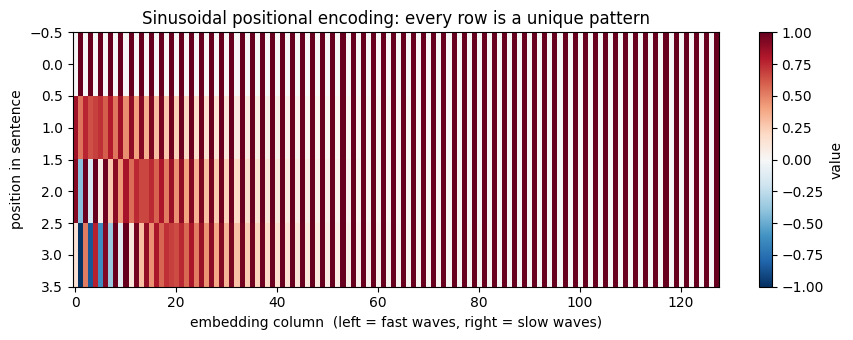

In [66]:
# ==========================================
# 2. POSITIONAL ENCODING (sine/cosine "seat numbers")
# ==========================================

# Setup matching dimensions from our token embedding output
sequence_length = embedded_sentence.shape[1]  # 4 words per sentence

def positional_encoding(sequence_length, dimension):
    # 1. Calculate the Position Matrix values using the formulas
    # pos shape: (seq_len, 1) -> [[0], [1], [2], [3]]
    position = torch.arange(0, sequence_length, dtype=torch.float32).unsqueeze(1)


    # 3. div_term creates the changing frequencies based on the column indices
    div_term = torch.exp(torch.arange(0, dimension, 2) *(-torch.log(torch.tensor(10000.0)) / dimension))

    # 3. Generate the Blank Positional Encoding Matrix (Shape: sequence_length, embedding_dim)
    pe = torch.zeros(sequence_length, dimension)
 
    # 4. Fill Even columns (0, 2, 4...) with Sine waves
    pe[:, 0::2] = torch.sin(position * div_term)
    # Fill Odd columns (1, 3...) with Cosine waves
    pe[:, 1::2] = torch.cos(position * div_term)

    # 5. Add the Batch Dimension to match the shape of embedded_sentence
    # Shape changes from (4, 128) → (1, 4, 128)
    pe = pe.unsqueeze(0)
    return pe

pe = positional_encoding(sequence_length, embedding_dimension)

# Add the semantic word vectors directly to the positional stamp vectors
final_transformer_input = embedded_sentence + pe

print("=== 1. POSITIONAL ENCODING MATRIX ===")
print("Positional encoding shape:", pe.shape)   # (1, positions, numbers per position)
print(pe[0, :, :8]) #shows the first 8 columns


print("=== 2. FINAL INTEGRATED TRANSFORMER INPUT ===")
print("Shape: Embeddings + positions   :", final_transformer_input.shape)
print(final_transformer_input.data)

print("Token 12 still identical in both sentences?", torch.equal(final_transformer_input[0, 0], final_transformer_input[1, 3]))   # Seat 0 vs seat 3

#Picture it - each row is one position's fingerprint
plt.figure(figsize=(9, 3.5))
plt.imshow(pe[0], cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")   # Blue = -1, white = 0, red = +1
plt.colorbar(label="value")
plt.xlabel("embedding column  (left = fast waves, right = slow waves)")
plt.ylabel("position in sentence")
plt.title("Sinusoidal positional encoding: every row is a unique pattern")
plt.tight_layout()
plt.show()

Read the picture left to right: the first columns flip colour every row or two (fast hands), the right-hand columns
barely change over 4 positions (slow hands) — which is why they show up as plain stripes: sine columns sit near 0
(white), cosine columns near 1 (red). No two rows are identical.

**Modern models don't all use this exact method.** GPT-2 and `tinyGpt.ipynb` use **learned** position embeddings
(just another `nn.Embedding`, indexed by position); Llama and most recent LLMs use **RoPE** (rotary embeddings, which
*rotate* the query and key vectors by an angle that depends on position). The goal is always the same: tell
attention where each word is.

### 3. Self-Attention — how words look at each other

This is the heart of the Transformer. Picture a **library visit**: you walk in with a **query** (*"I need something
about sleepy animals"*). Every book has a **key** (the label on its spine) and a **value** (what's actually inside).
You compare your query against every key, score how well each matches, and walk out with a **blend** of the books'
contents — mostly from the best matches, a little from the rest.

In a sentence, **every word does this at once**: each word is a reader (query) *and* a book (key + value) for all
the others. It takes four steps — **score, scale, soften, blend**:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

| Step | Maths | Plain English |
|---|---|---|
| 1. Score | $QK^\top$ | Dot product: how well does each query match each key? |
| 2. Scale | $\div \sqrt{d_k}$ | Shrink the scores so softmax doesn't become winner-takes-all ($d_k$ = numbers per key) |
| 3. Soften | softmax | Turn each row of scores into percentages that add up to 1 (the **attention weights**) |
| 4. Blend | $\times V$ | Each word's output = weighted average of all the values |

Let's do it by hand with 2 tiny words, each described by 2 numbers.

In [67]:
# ==========================================
# 3A. SELF-ATTENTION BY HAND (NumPy, 2 words × 2 numbers)
# ==========================================


Q = np.array([[1.0, 0.0],     # Word 1's question: "what am I looking for?"
              [0.0, 1.0]])    # Word 2's question
K = np.array([[1.0, 0.0],     # Word 1's label: "what do I contain?"
              [0.5, 1.0]])    # Word 2's label
V = np.array([[2.0, 1.0],     # Word 1's content: "what I share if picked"
              [1.0, 3.0]])    # Word 2's content

# Step 1 - SCORE: every query dotted with every key. Row = the reader, column = the book
scores = Q @ K.T
print("1. Raw scores (row i = how much word i matches each word):\n", scores)

# Step 2 - SCALE: divide by √d_k so bigger vectors don't give giant scores
d_k = K.shape[1]
scaled = scores / np.sqrt(d_k)
print("\n2. Scaled scores (÷ √2):\n", scaled)

# Step 3 - SOFTEN: softmax each row so it becomes percentages adding to 1
def softmax(z):
    e = np.exp(z - z.max(axis=-1, keepdims=True))   # Subtract the max first - avoids overflow, same answer
    return e / e.sum(axis=-1, keepdims=True)

weights = softmax(scaled)
print("\n3. Attention weights (each row sums to 1):\n", weights)
print("   Row sums:", weights.sum(axis=1))

# Step 4 - BLEND: each word's new vector = weighted mix of every word's value
output = weights @ V
print("\n4. Output (each word now carries context from the other):\n", output)

1. Raw scores (row i = how much word i matches each word):
 [[1.  0.5]
 [0.  1. ]]

2. Scaled scores (÷ √2):
 [[0.707 0.354]
 [0.    0.707]]

3. Attention weights (each row sums to 1):
 [[0.587 0.413]
 [0.33  0.67 ]]
   Row sums: [1. 1.]

4. Output (each word now carries context from the other):
 [[1.587 1.825]
 [1.33  2.34 ]]


Read row 1 of the weights: word 1 spends **~59%** of its attention on itself and **~41%** on word 2, so its output
`[1.587, 1.825]` is mostly word 1's value `[2, 1]` with a good dose of word 2's value `[1, 3]` mixed in. The word
went in "alone" and came out **aware of its neighbour** — that's what "contextual representation" means.

**Where do Q, K and V come from?** Above we typed them in. In a real model they are all made **from the same input
vectors `x`**, each through its own learned linear layer (a learned "translation"). Same word, three roles. That's
why it's called *self*-attention: the sentence attends to itself.

In [69]:
# ==========================================
# 3B. SELF-ATTENTION IN PYTORCH (Q, K, V learned from the same input)
# ==========================================


# 1. Define Linear projections to create Q, K, V matrices
# In a real transformer, these weights are learned during training
W_q = nn.Linear(embedding_dimension, embedding_dimension, bias=False)
W_k = nn.Linear(embedding_dimension, embedding_dimension, bias=False)
W_v = nn.Linear(embedding_dimension, embedding_dimension, bias=False)


# Project our input into Queries, Keys, and Values
Q = W_q(final_transformer_input)  # Shape: (2, 4, 128)
K = W_k(final_transformer_input)  # Shape: (2, 4, 128)
V = W_v(final_transformer_input)  # Shape: (2, 4, 128)


print("=== 1. MATRICES GENERATED ===")
print("Query (Q) Shape:", Q.shape)
print("Key (K) Shape:", K.shape)
print("Value (V) Shape:", V.shape, "\n")

# 2. Step-by-Step Attention Math
# Step A: Compute Raw Scores (Q multiplied by transposed K)
# We use torch.matmul and transpose the last two dimensions of K
scores = torch.matmul(Q, K.transpose(-2, -1))  # Shape: (2, 4, 4)
print("A. Raw scores (row i = how much word i matches each word):\n", scores)

# Step B: Scale the scores
d_k = K.size(-1)
scaled_scores = scores / math.sqrt(d_k)
print(f"\nB. Scaled scores (÷ √{d_k}):\n", scaled_scores)


# Step C: Apply Softmax to get Attention Weights (Percentages)
attention_weights = torch.softmax(scaled_scores, dim=-1)
print("=== C. ATTENTION WEIGHTS (PROBABILITIES) ===")
print("Shape:", attention_weights.shape, "-> (Batch, Word_Q, Word_K)")
print("Row sums:", attention_weights.sum(dim=-1))
print(attention_weights.data, "\n")


# Step D: Multiply weights by Values (V) to get final context output
attention_output = torch.matmul(attention_weights, V)  # Shape: (2, 4, 128)

print("=== D. FINAL SELF-ATTENTION OUTPUT ===")
print("Shape:", attention_output.shape, "-> (Batch, Seq_Len, Embedding_Dim)")
print(attention_output.data)



=== 1. MATRICES GENERATED ===
Query (Q) Shape: torch.Size([2, 4, 128])
Key (K) Shape: torch.Size([2, 4, 128])
Value (V) Shape: torch.Size([2, 4, 128]) 

A. Raw scores (row i = how much word i matches each word):
 tensor([[[  8.397,   4.040,   6.175,   3.227],
         [  6.192,  -6.658,  16.473,   5.910],
         [ -1.758,  -1.248,   3.295,   3.864],
         [ 13.140,   0.412,   9.165,   9.276]],

        [[ -2.371,  -1.599, -11.330,  -2.225],
         [  2.700,   0.167,   3.464,   5.901],
         [  6.376,  -1.249,  -9.841,   4.960],
         [  6.123,   9.368,   6.422,   9.819]]], grad_fn=<UnsafeViewBackward0>)

B. Scaled scores (÷ √128):
 tensor([[[ 0.742,  0.357,  0.546,  0.285],
         [ 0.547, -0.588,  1.456,  0.522],
         [-0.155, -0.110,  0.291,  0.341],
         [ 1.161,  0.036,  0.810,  0.820]],

        [[-0.210, -0.141, -1.001, -0.197],
         [ 0.239,  0.015,  0.306,  0.522],
         [ 0.564, -0.110, -0.870,  0.438],
         [ 0.541,  0.828,  0.568,  0.868]]],

The weights are spread out fairly evenly because the linear layers are random — nothing has been learned yet. After
training, a row like *"it"* in *"the animal didn't cross the street because **it** was tired"* concentrates its
weight on *"animal"*.

The output has the **same shape as the input**: 4 words × 128 numbers in, 4 words × 128 numbers out. That's what lets us
stack attention layers on top of each other.

### 4. Masks — rules about who may look at whom

Sometimes a word must **not** be allowed to look at certain other words. The trick is always the same: set the
forbidden scores to **−∞** before softmax. Since $e^{-\infty} = 0$, those words get **exactly 0%** attention, and the
remaining percentages still add up to 1.

- **Causal mask (no peeking at the future)** — used by every text generator (GPT, Claude, the decoder). When the
  model learns to predict word 4, it must only see words 1–3, otherwise it would just copy the answer. The mask is a
  lower triangle: row *i* can see columns 0…*i*.
- **Padding mask (ignore the filler)** — sentences in a batch have different lengths, so short ones get padded with
  a dummy `<pad>` token to line them up. Nobody should pay attention to padding.

Causal mask (1 = allowed, 0 = blocked):
 tensor([[1, 0, 0, 0],
        [1, 1, 0, 0],
        [1, 1, 1, 0],
        [1, 1, 1, 1]], dtype=torch.int32)
=== 1. SCORES AFTER CAUSAL MASK ===
tensor([[-0.675,   -inf,   -inf,   -inf],
        [ 0.237,  1.022,   -inf,   -inf],
        [ 0.017,  0.249,  0.146,   -inf],
        [ 0.260, -0.175,  0.232,  0.343]]) 

=== 2. FINAL ATTENTION WEIGHTS (PROBABILITIES) ===
tensor([[1.000, 0.000, 0.000, 0.000],
        [0.313, 0.687, 0.000, 0.000],
        [0.294, 0.371, 0.335, 0.000],
        [0.270, 0.175, 0.262, 0.293]])

Attention weights with padding mask (last 2 columns are <pad>):
 tensor([[0.434, 0.566, 0.000, 0.000],
        [0.313, 0.687, 0.000, 0.000],
        [0.442, 0.558, 0.000, 0.000],
        [0.607, 0.393, 0.000, 0.000]])


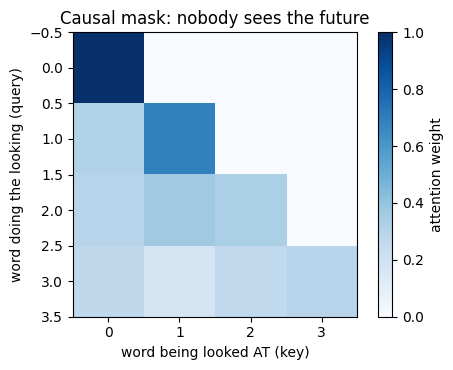

In [68]:
# ==========================================
# 4. MASKS (causal + padding)
# ==========================================
scaled_4x4 = scaled_scores[0].detach()   # Sentence 1's 4×4 scaled scores from section 3B
seq_len = sequence_length

# 1. Create a Causal Mask (Upper Triangular Matrix)
# torch.triu creates an upper triangle of 1s. diagonal=1 keeps the main diagonal open (0).
mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1)
# Resulting mask matrix (1 = blocked):
# [[0, 1, 1, 1],
#  [0, 0, 1, 1],
#  [0, 0, 0, 1],
#  [0, 0, 0, 0]]

# 2. Convert 1s to negative infinity, and 0s to 0.0
causal_mask = mask.masked_fill(mask == 1, float('-inf'))
# Resulting causal_mask:
# [[0.0, -inf, -inf, -inf],
#  [0.0,  0.0, -inf, -inf],
#  [0.0,  0.0,  0.0, -inf],
#  [0.0,  0.0,  0.0,  0.0]]

print("Causal mask (1 = allowed, 0 = blocked):\n", (mask == 0).int())

# 3. Add the mask to the scaled scores
# Anything added to -inf becomes -inf
masked_scores = scaled_4x4 + causal_mask

# 4. Pass through Softmax to get the final attention weights
causal_attention_weights = torch.softmax(masked_scores, dim=-1)

print("=== 1. SCORES AFTER CAUSAL MASK ===")
print(masked_scores.data, "\n")

print("=== 2. FINAL ATTENTION WEIGHTS (PROBABILITIES) ===")
# Notice how the upper right triangle is exactly 0
print(torch.round(causal_attention_weights, decimals=4).data)


# 5. Padding mask - pretend the last 2 of our 4 tokens are <pad> filler
is_real = torch.tensor([True, True, False, False])
pad_weights = torch.softmax(scaled_4x4.masked_fill(~is_real, float('-inf')), dim=-1)
print("\nAttention weights with padding mask (last 2 columns are <pad>):\n", pad_weights)

# 6. Picture the causal pattern
plt.figure(figsize=(5, 3.8))
plt.imshow(causal_attention_weights, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(label="attention weight")
plt.xlabel("word being looked AT (key)")
plt.ylabel("word doing the looking (query)")
plt.title("Causal mask: nobody sees the future")
plt.tight_layout()
plt.show()

Everything above the diagonal is exactly 0 — the future is invisible. With the padding mask, the last two columns are
0 for every word, so the filler contributes nothing to anyone's output.

In PyTorch's built-in layers you rarely build these by hand: `nn.Transformer.generate_square_subsequent_mask(n)`
makes the causal mask, and `key_padding_mask=` / `src_key_padding_mask=` take the padding mask (**careful**: there,
`True` means *"ignore this position"* — the opposite of our `is_real`).

### 5. Multi-Head Attention — several readers at once

One attention pattern gives each word **one way** of looking at the sentence. But language has many relationships at
the same time: which noun does *"it"* refer to, which adjective describes which noun, which verb goes with which
subject…

**Multi-head attention** runs several attention "heads" side by side, like a team of readers each hunting for a
different kind of clue. The 128 numbers per word are **split** between the heads (8 heads × 16 numbers each), every
head does its own score–scale–soften–blend, and the results are glued back together and mixed by one final linear
layer. Splitting (rather than copying) means 8 heads cost about the same as 1 big head.

In [70]:
# ==========================================
# 5. MULTI-HEAD ATTENTION
# ==========================================

num_heads = 8
batch_size = final_transformer_input.shape[0] # 2 sentences,
d_k = embedding_dimension // num_heads  # Dimension per head = 16 (128 / 8)
print("Numbers each head works with:", d_k)


# 1. Define the linear projections for the entire d_model size
W_q = nn.Linear(embedding_dimension, embedding_dimension, bias=False)
W_k = nn.Linear(embedding_dimension, embedding_dimension, bias=False)
W_v = nn.Linear(embedding_dimension, embedding_dimension, bias=False)
out_project = nn.Linear(embedding_dimension, embedding_dimension)


# 2. Project to get Q, K, V
Q = W_q(final_transformer_input) # (2, 4, 128)
K = W_k(final_transformer_input) # (2, 4, 128)
V = W_v(final_transformer_input) # (2, 4, 128)


# 3. THE SPLIT STEP: Reshape and Permute to separate the heads
# From (2, 4, 128) -> view (2, 4, 8, 16) -> transpose (2, 8, 4, 16) = (Batch, Heads, Seq_Len, d_k)
Q = Q.view(batch_size, sequence_length, num_heads, d_k).transpose(1, 2)
K = K.view(batch_size, sequence_length, num_heads, d_k).transpose(1, 2)
V = V.view(batch_size, sequence_length, num_heads, d_k).transpose(1, 2)


print("=== 1. HEAD SPLIT CONFIGURATION ===")
print("Shape of Q per head:", Q.shape, "-> (Batch, Heads, Seq_Len, Dim_Per_Head)\n")

# 4. Standard Attention Math calculated across all heads simultaneously
scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
attention_weights = torch.softmax(scores, dim=-1) # (2, 8, 4, 4): one 4×4 pattern per head
head_outputs = torch.matmul(attention_weights, V) 	# (2, 8, 4, 16)


# 5. THE MERGE STEP: Concatenate heads back together
# Permute back to (Batch, Seq_Len, Heads, d_k) -> (2, 4, 8, 16)
# Then flatten the last two dimensions back into d_model 	-> (2, 4, 128)
merged_heads = head_outputs.transpose(1, 2).contiguous().view(batch_size, sequence_length, embedding_dimension)

print("=== 2. MERGED HEADS COMPOSITE ===")
print("Shape after merging heads:", merged_heads.shape, "-> (Batch, Seq_Len, d_model)\n")

# 6. Final linear transformation
final_attention_output = out_project(merged_heads)
print("=== 3. FINAL LAYER TRANSFORMED OUTPUT ===")
print("Output Shape:", final_attention_output.shape)
print("Attention weights:", attention_weights.shape)



Numbers each head works with: 16
=== 1. HEAD SPLIT CONFIGURATION ===
Shape of Q per head: torch.Size([2, 8, 4, 16]) -> (Batch, Heads, Seq_Len, Dim_Per_Head)

=== 2. MERGED HEADS COMPOSITE ===
Shape after merging heads: torch.Size([2, 4, 128]) -> (Batch, Seq_Len, d_model)

=== 3. FINAL LAYER TRANSFORMED OUTPUT ===
Output Shape: torch.Size([2, 4, 128])
Attention weights: torch.Size([2, 8, 4, 4])


The weights shape shows the point: **8 separate 4×4 attention patterns per sentence**, one per head. The parameter
count is $3 \times 128 \times 128 +  (128 \times 128 + 128) = 65{,}664$ — the Q, K, V and output projections. The number of heads does
**not** change it.

### 6. Add & Norm — residual connections and layer normalization

Every sub-layer (attention, feed-forward) is wrapped in two helpers:

- **Add (residual connection)**: output = input **+** sub-layer(input). The sub-layer only has to learn a *correction*
  to what's already there, not rebuild the word from scratch. It's also a highway for gradients (the learning
  signal) to flow straight back through a deep stack of layers — without it, 12, 24 or 96 layers wouldn't train.
- **Norm (LayerNorm)**: rescales each word's numbers to average 0 and spread 1, so values can't slowly blow up or
  shrink as they pass through layer after layer. Like re-tuning an instrument between songs.

In [71]:
# ==========================================
# 6. ADD & NORM
# ==========================================

# LayerNorm used after attention
norm1 = nn.LayerNorm(embedding_dimension)

# 1. "Add" the original input to the attention output
x_residual_1 = final_transformer_input + final_attention_output
# 2. "Norm" the combined result
x_norm_1 = norm1(x_residual_1)

print(f"Before norm → average {x_residual_1.mean():.2f}, spread {x_residual_1.std():.2f}")
print(f"After norm  → average {x_norm_1.mean():.2f}, spread {x_norm_1.std():.2f}")
print("=== POST ADD & NORM  ===")
print("Shape:", x_norm_1.shape)
print("Mean value per feature row (should be close to 0):")
print(torch.round(x_norm_1.mean(dim=-1), decimals=4).data, "\n")



Before norm → average 0.44, spread 1.12
After norm  → average 0.00, spread 1.00
=== POST ADD & NORM  ===
Shape: torch.Size([2, 4, 128])
Mean value per feature row (should be close to 0):
tensor([[-0., 0., 0., 0.],
        [0., 0., 0., 0.]]) 



**Post-norm vs pre-norm.** The original paper (and the code above) normalizes *after* adding:
`LayerNorm(x + sublayer(x))`. Almost every modern model (GPT-2 onward, `tinyGpt.ipynb`) normalizes *before* the
sub-layer instead: `x + sublayer(LayerNorm(x))` — it trains more stably when stacking many layers. In PyTorch's
built-in layers this is the `norm_first=True` switch.

### 7. Position-wise Feed-Forward Network — each word thinks on its own

Attention is where words **talk to each other**. The feed-forward network (FFN) is where each word **thinks by itself**
about what it just heard. It's a small two-layer network applied to every word **separately** (that's what
"position-wise" means — same network, each position on its own, no mixing between words).

It widens each word's vector (128 → 512, the usual 4×), applies a non-linearity (GELU here; the original paper used ReLU, and Llama-style models use SwiGLU), then shrinks it back to 128 so the next layer gets the same shape.

In [72]:
# ==========================================
# 7. POSITION-WISE FEED-FORWARD NETWORK
# ==========================================

# LayerNorm for the second Add & Norm
norm2 = nn.LayerNorm(embedding_dimension)

#  Define the FFN layers
# Standard practice expands d_model dimension (typically 4x) then projects it back
d_ff = embedding_dimension * 4  # 512 (128 × 4).
ffn_layer1 = nn.Linear(embedding_dimension, d_ff)
ffn_activation = nn.GELU()  # Modern standard activation function
ffn_layer2 = nn.Linear(d_ff, embedding_dimension)

# 1. Expand feature space
ffn_out = ffn_layer1(x_norm_1)
# 2. Apply non-linear activation
ffn_out = ffn_activation(ffn_out)
# 3. Project back to original d_model size
ffn_processed = ffn_layer2(ffn_out)

print("=== POST FFN PROCESSING ===")
print("Shape:", ffn_processed.shape, "-> (Preserves original layout)\n")
# Proof it's position-wise: word 3 run alone gives the same answer as word 3 inside the sentence
alone = ffn_layer2(ffn_activation(ffn_layer1(x_norm_1[:, 3:4, :])))
print("Word 3 alone == word 3 in the sentence:", torch.allclose(alone, ffn_processed[:, 3:4, :], atol=1e-6))

ffn_params  = sum(p.numel() for layer in (ffn_layer1, ffn_layer2) for p in layer.parameters())
attn_params = sum(p.numel() for layer in (W_q, W_k, W_v, out_project) for p in layer.parameters())
print(f"Feed-forward parameters: {ffn_params:,}")        # 131,712
print(f"Attention parameters   : {attn_params:,}")       # 65,664
print(f"Share held by the FFN  : {ffn_params / (ffn_params + attn_params):.0%}")   # 67%




#  Second Add & Norm (Residual connection around the FFN)
# 1. "Add" the pre-FFN vector to the post-FFN vector
x_residual_2 = x_norm_1 + ffn_processed
# 2. Final "Norm" equalization
final_block_output = norm2(x_residual_2)

print("===  FINAL TRANSFORMER BLOCK OUTPUT ===")
print("Shape:", final_block_output.shape)



=== POST FFN PROCESSING ===
Shape: torch.Size([2, 4, 128]) -> (Preserves original layout)

Word 3 alone == word 3 in the sentence: True
Feed-forward parameters: 131,712
Attention parameters   : 65,664
Share held by the FFN  : 67%
===  FINAL TRANSFORMER BLOCK OUTPUT ===
Shape: torch.Size([2, 4, 128])


The humble FFN holds **about two thirds** of each layer's weights. Attention decides *where information flows*; the
feed-forward layers do much of the *storing and transforming* — a lot of what a large language model "knows" is
thought to live in them.

### 8. Putting It Together — one Transformer block from scratch

Now we snap sections 5–7 together into the unit that gets stacked 12, 24, 96… times in real models — using
the **pre-norm** layout from the note after section 6 (sections 6–7 used post-norm):

```
x ─┬─> LayerNorm ─> Multi-Head Attention ─> (+) ─┬─> LayerNorm ─> Feed-Forward ─> (+) ─> out
   └─────────────────────────────────────────┘   └─────────────────────────────────┘
              residual connection                       residual connection
```

Then we check it against PyTorch's `nn.TransformerEncoderLayer`: if we've understood every piece, the two should
have **exactly the same number of weights**.

In [73]:
# ==========================================
# 8. ONE TRANSFORMER BLOCK FROM SCRATCH
# ==========================================
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model=128, num_heads=8, dim_feedforward=512,dropout=0.1):
        """
        A single reusable Transformer Encoder Block.
        
        Args:
            d_model (int): The embedding / feature dimension.
            num_heads (int): Number of parallel attention heads.
            dim_feedforward (int): The hidden layer size of the Feed-Forward Network.
            dropout (float): Dropout probability for regularization.
        """
        super().__init__()
        # 1. Multi-Head Attention Sub-layer
        # We use PyTorch's highly optimized built-in MultiheadAttention layer
        self.attention = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads, batch_first=True)
        
        # 2. Feed-Forward Network (FFN) Sub-layer
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(), # Modern non-linear activation function
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model)
        )
        
        # 3. Layer Normalization Modules
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        # 4. Dropout layers for regularization
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        """
        Forward pass workflow.
        
        Args:
            x (Tensor): Input tensor of shape (batch_size, seq_len, d_model)
            mask (Tensor, optional): Attention mask (Causal or Padding). Default is None.
            
        Returns:
            Tensor: Processed tensor of shape (batch_size, seq_len, d_model)
        """
         # -------------------------------------------------------------
        # STEP 1: Attention Sub-Layer (Pre-LN design)
        # -------------------------------------------------------------
        # A. Pre-Normalize the incoming tensor
        norm_x = self.norm1(x)
        
        # B. Compute Attention. PyTorch's MultiheadAttention returns (output, weights).
        # We pass norm_x as Query, Key, and Value simultaneously.
        attn_output, _ = self.attention(query=norm_x, key=norm_x, value=norm_x, attn_mask=mask)
        
        # C. Apply Dropout and ADD the residual connection (Original 'x')
        x = x + self.dropout1(attn_output)
        
        # -------------------------------------------------------------
        # STEP 2: Feed-Forward Network Sub-Layer
        # -------------------------------------------------------------
        # A. Pre-Normalize the integrated tensor
        norm_x2 = self.norm2(x)
        
        # B. Process through FFN layers
        ffn_output = self.ffn(norm_x2)
        
        # C. Apply Dropout and ADD the second residual connection
        x = x + self.dropout2(ffn_output)
        
        return x

# Define parameters matching standard compact configs
BATCH_SIZE = 2
SEQ_LEN = 4
D_MODEL = 128        # Embedding dimension (must be divisible by NUM_HEADS)
NUM_HEADS = 8       # Each head handles 16 dimensions (128 / 8)
DIM_FFN = 512        # 4 × 128

# 1. Instantiate the reusable block module
transformer_block = TransformerEncoderBlock(
    d_model=D_MODEL, 
    num_heads=NUM_HEADS, 
    dim_feedforward=DIM_FFN,
    dropout=0.1
)



print("=== MODEL VERIFICATION ===")

# Run forward computation pass
model_output = transformer_block(final_transformer_input)

print("Output Tensor Shape:", model_output.shape)
# 3. Compare with PyTorch's built-in version (same settings: GELU, pre-norm)
builtin = nn.TransformerEncoderLayer(d_model=D_MODEL, nhead=NUM_HEADS, dim_feedforward=DIM_FFN,
                                     dropout=0.1, activation="gelu", batch_first=True, norm_first=True)
count = lambda m: sum(p.numel() for p in m.parameters())   # Add up every weight and bias
print(f"Our block parameters      : {count(transformer_block):,}")   # 198,272
print(f"nn.TransformerEncoderLayer: {count(builtin):,}")             # 198,272

=== MODEL VERIFICATION ===
Output Tensor Shape: torch.Size([2, 4, 128])
Our block parameters      : 198,272
nn.TransformerEncoderLayer: 198,272


Identical counts: attention (66,048) + feed-forward (131,712) + two LayerNorms (2 × 256) = **198,272**. There's
nothing hidden inside PyTorch's layer that you haven't just written yourself (the built-in one adds dropout and fast
fused kernels, which change speed, not the design).

### 9. Output Layer & Softmax — from vectors to a prediction

After the last block, each position's vector goes through one final linear layer that produces a **score (logit)**
for every word in the vocabulary, and softmax turns those scores into probabilities.

How we then **pick** the next word is called the **decoding strategy**:
- **Greedy** — always take the highest-probability word. Safe but repetitive.
- **Sampling with temperature** — roll a weighted die. Divide the logits by a *temperature* first: below 1 makes the
  model more confident/boring, above 1 more adventurous/random.
- **Top-k** — only roll the die among the *k* most likely words, so absurd picks are impossible.

In [11]:
# ==========================================
# 9. OUTPUT LAYER, SOFTMAX AND DECODING
# ==========================================
vocab = ["mat", "sofa", "moon", "roof"]      # A tiny 4-word vocabulary for "the cat sat on the ..."
logits = torch.tensor([[2.1, 1.2, 0.4, 3.0]])   # Raw scores from the final linear layer

# Step A: Softmax turns scores into probabilities that add up to 1
probabilities = F.softmax(logits, dim=-1)
for word, p in zip(vocab, probabilities[0]):
    print(f"  {word:5s} {p:.1%}")
print("Sum:", probabilities.sum().item())

# Step B: Greedy - just take the top one
print("\nGreedy pick:", vocab[probabilities.argmax()])

# Step C: Temperature reshapes the odds before sampling
for temperature in [0.5, 1.0, 2.0]:
    p = F.softmax(logits / temperature, dim=-1)[0]
    print(f"Temperature {temperature}: " + "  ".join(f"{w} {q:.0%}" for w, q in zip(vocab, p)))

# Step D: Top-k sampling (k=2) - only the 2 best candidates stay in the draw
top_values, top_ids = logits.topk(2)
pick = top_ids[0, torch.multinomial(F.softmax(top_values, dim=-1)[0], 1)]
print("\nTop-2 candidates:", [vocab[i] for i in top_ids[0]], "→ sampled:", vocab[pick])

  mat   24.7%
  sofa  10.0%
  moon  4.5%
  roof  60.7%
Sum: 1.0

Greedy pick: roof
Temperature 0.5: mat 14%  sofa 2%  moon 0%  roof 83%
Temperature 1.0: mat 25%  sofa 10%  moon 5%  roof 61%
Temperature 2.0: mat 28%  sofa 18%  moon 12%  roof 43%

Top-2 candidates: ['roof', 'mat'] → sampled: roof


Low temperature (0.5) pushes almost everything onto *"roof"*; high temperature (2.0) flattens the odds so even
*"moon"* gets a real chance. That's the "creativity" slider you see in chatbot APIs.

## Part 2 — The Full Architecture

### 10. Encoder–Decoder: the original design

The original Transformer (*"Attention Is All You Need"*, 2017) was built for **translation**, and has two halves:

- **Encoder** — reads the whole input sentence (e.g. English) with **no mask**: every word sees every other word,
  past and future. Output: one context-rich vector per input word, called the **memory**.
- **Decoder** — writes the output sentence (e.g. French) **one word at a time**. Each decoder layer has **three**
  sub-layers, not two:
  1. **Masked self-attention** — looks at the French words written so far (causal mask, no peeking).
  2. **Cross-attention** — the *queries* come from the decoder, the *keys and values* come from the encoder's
     memory. This is the moment the translator glances back at the English sentence.
  3. **Feed-forward**, as usual (each with Add & Norm).

```
English: "the cat sat"                      French so far: "<start> le chat"
        ↓                                            ↓
   ┌─────────┐    memory (K, V)             ┌──────────────────────────┐
   │ ENCODER │ ───────────────────────────> │ DECODER                  │
   │ N blocks│                              │ masked self-attention    │
   └─────────┘                              │ cross-attention ←memory  │
                                            │ feed-forward             │
                                            └──────────────────────────┘
                                                     ↓
                                            next word: "s'est"
```

In [12]:
# ==========================================
# 10A. THE ENCODER WORKFLOW
# ==========================================
encoder_layer = nn.TransformerEncoderLayer(
    d_model=128,           # Numbers per token
    nhead=8,               # Attention heads
    dim_feedforward=512,   # Width of the feed-forward "thinking" layer
    batch_first=True
)
encoder = nn.TransformerEncoder(encoder_layer, num_layers=4)   # Stack 4 copies of the block

src = torch.randn(2, 20, 128)   # 2 source sentences, 20 tokens each (embeddings + positions)

# Sentence 2 is really only 16 tokens long - the last 4 are <pad>. True = "ignore this position"
src_padding = torch.zeros(2, 20, dtype=torch.bool)
src_padding[1, 16:] = True

memory = encoder(src, src_key_padding_mask=src_padding)
print("Encoder output (memory) shape:", memory.shape)   # One contextual vector per input token

Encoder output (memory) shape: torch.Size([2, 20, 128])


In [13]:
# ==========================================
# 10B. THE DECODER WORKFLOW
# ==========================================
decoder_layer = nn.TransformerDecoderLayer(
    d_model=128,
    nhead=8,
    dim_feedforward=512,
    batch_first=True
)
decoder = nn.TransformerDecoder(decoder_layer, num_layers=4)

target = torch.randn(2, 15, 128)   # The output sentence so far: 15 tokens (embeddings + positions)

# Causal mask: 0 where looking is allowed, -inf where it's the future
causal_mask = nn.Transformer.generate_square_subsequent_mask(15)
print("Causal mask (top-left 5×5 corner):\n", causal_mask[:5, :5])

decoded = decoder(
    target,
    memory,                                    # Cross-attention looks here (the encoder's output)
    tgt_mask=causal_mask,                      # No peeking at future output words
    memory_key_padding_mask=src_padding        # Don't glance back at the source's <pad> tokens
)
print("\nDecoder output shape:", decoded.shape)   # One vector per OUTPUT token

# Proof the mask works: changing the LAST target word must not change the output at earlier positions
target_changed = target.clone()
target_changed[:, -1] = torch.randn(128)
decoder.eval()   # Switch off dropout so both runs are comparable
with torch.no_grad():
    a = decoder(target, memory, tgt_mask=causal_mask, memory_key_padding_mask=src_padding)
    b = decoder(target_changed, memory, tgt_mask=causal_mask, memory_key_padding_mask=src_padding)
print("Earlier positions unaffected by a future word:", torch.allclose(a[:, :-1], b[:, :-1], atol=1e-5))
print("Last position did change                     :", not torch.allclose(a[:, -1], b[:, -1], atol=1e-5))

Causal mask (top-left 5×5 corner):
 tensor([[0., -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0.]])

Decoder output shape: torch.Size([2, 15, 128])
Earlier positions unaffected by a future word: True
Last position did change                     : True


The last check is the whole point of the causal mask: we changed word 15 and positions 1–14 didn't move at all. So
during training we can feed the **entire** correct target sentence in one go (called **teacher forcing**) and every
position still only learns from the words before it — 15 training examples in a single pass.

### 11. A Complete (Tiny) Translation Model

Sections 1–10 in one class: embeddings → positions → `nn.Transformer` (encoder + decoder) → output layer. Then the
**generation loop**: at prediction time there's no correct answer to feed in, so the decoder starts with a `<start>`
token, predicts one word, appends it, and runs again — until it predicts `<end>`.

The model below is **untrained**, so the words it picks are random. The point is the plumbing and the loop, which are
exactly the same in a trained translator.

In [14]:
# ==========================================
# 11. A COMPLETE ENCODER-DECODER MODEL
# ==========================================
class TinyTranslator(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model=128, max_len=100):
        super().__init__()
        self.src_embed = nn.Embedding(src_vocab, d_model)      # 1. Source word IDs → vectors
        self.tgt_embed = nn.Embedding(tgt_vocab, d_model)      #    Target word IDs → vectors
        self.register_buffer("pe", positional_encoding(max_len, d_model))   # 2. Seat numbers (not learned)
        self.transformer = nn.Transformer(                     # 3–8. Encoder + decoder stacks
            d_model=d_model, nhead=8, num_encoder_layers=2, num_decoder_layers=2,
            dim_feedforward=512, batch_first=True
        )
        self.to_vocab = nn.Linear(d_model, tgt_vocab)          # 9. Vector → a score per target word

    def forward(self, src_ids, tgt_ids):
        src = self.src_embed(src_ids) + self.pe[: src_ids.shape[1]]
        tgt = self.tgt_embed(tgt_ids) + self.pe[: tgt_ids.shape[1]]
        mask = nn.Transformer.generate_square_subsequent_mask(tgt_ids.shape[1])
        out = self.transformer(src, tgt, tgt_mask=mask)
        return self.to_vocab(out)                              # Logits: (batch, target length, target vocab)

START, END = 1, 2                                               # Special token IDs
model = TinyTranslator(src_vocab=1000, tgt_vocab=1200)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# Training shape check: feed the whole target at once (teacher forcing)
src_ids = torch.randint(3, 1000, (2, 12))   # 2 English sentences, 12 tokens
tgt_ids = torch.randint(3, 1200, (2, 9))    # Their French translations so far, 9 tokens
print("Logits shape:", model(src_ids, tgt_ids).shape, "→ a score for every French word, at every position")

# Generation: greedy, one word at a time
model.eval()
with torch.no_grad():
    generated = torch.tensor([[START]])                  # Step A: begin with <start>
    for _ in range(6):
        logits = model(src_ids[:1], generated)           # Step B: run on everything written so far
        next_id = logits[0, -1].argmax()                 # Step C: only the LAST position predicts the next word
        generated = torch.cat([generated, next_id.view(1, 1)], dim=1)   # Step D: append and repeat
        if next_id == END:
            break
print("Generated token IDs:", generated[0].tolist(), "(random - the model is untrained)")

Total parameters: 1,362,608
Logits shape: torch.Size([2, 9, 1200]) → a score for every French word, at every position
Generated token IDs: [1, 235, 943, 679, 843, 943, 100] (random - the model is untrained)


### 12. Three Families of Transformers

Almost every famous model keeps only one half, or both, of the original design:

| Family | Which parts | Attention mask | Good at | Famous examples | In this repo |
|---|---|---|---|---|---|
| **Encoder-only** | Encoder stack | None — sees the whole text both ways | Understanding: classification, search, tagging | BERT, RoBERTa, DistilBERT | `sentimentTransformer.ipynb` |
| **Decoder-only** | Decoder stack **without** cross-attention | Causal | Generating text, next-word prediction, chat | GPT, Claude, Llama | `tinyGpt.ipynb` |
| **Encoder–decoder** | Both + cross-attention | None in encoder, causal in decoder | Turning one sequence into another: translation, summarising | Original Transformer, T5, BART | Section 11 above |

In PyTorch terms: an encoder-only model is `nn.TransformerEncoder` + a small classifier head on top; a decoder-only
model is *also* built from `nn.TransformerEncoderLayer` blocks — just with a causal mask passed in — because without
cross-attention a "decoder" block is identical to an encoder block.

## Part 3 — Limitations of Transformer Architecture

1. **High computational requirements.** Every word is compared with every other word, so the work grows with the
   **square** of the text length: double the text, four times the attention work. (The cell below puts numbers on it.)
2. **Memory consumption.** The same square shows up in memory — an *n × n* attention table per head, per layer — plus,
   at generation time, the **KV cache** (the stored keys and values of every earlier word, so they aren't recomputed).
   Tricks like FlashAttention avoid ever storing the full table, but the amount of *work* is still squared.
3. **Fixed context window.** A model can only attend to so many tokens at once (its context length). Anything
   beyond that is simply invisible to it unless extra machinery (retrieval, summarising) feeds it back in.
4. **Large training and data requirements.** Attention has almost no built-in assumptions about language (unlike a
   CNN's "nearby pixels matter" or an RNN's "order matters") — it has to *learn* all of that from examples. That
   flexibility is why transformers scale so well, but it also means they need huge datasets and lots of compute.
   On small datasets, simpler models often win (compare Phase 7, where bag-of-words beat an LSTM on IMDB).
5. **Hallucination.** A language model is trained to produce the most *plausible* next word, not the most *true* one.
   When it doesn't know, it can still write a fluent, confident, wrong answer.
6. **Hard to interpret.** Attention weights show *where* a model looked, but not really *why* it made a decision.
   Understanding what billions of weights have learned is an open research area.

In [15]:
# ==========================================
# LIMITATION 1 & 2 IN NUMBERS: THE QUADRATIC COST
# ==========================================
# Memory for ONE full attention table (n × n scores, 4 bytes each) - for one head, in one layer
print(f"{'tokens':>8} | {'scores in table':>16} | {'memory (1 head, 1 layer)':>24}")
for n in [512, 2_048, 8_192, 32_768, 131_072]:
    scores_count = n * n
    megabytes = scores_count * 4 / 1024**2
    size = f"{megabytes:,.0f} MB" if megabytes < 1024 else f"{megabytes / 1024:,.0f} GB"
    print(f"{n:>8,} | {scores_count:>16,} | {size:>24}")
# Real models have dozens of heads and layers on top of this

  tokens |  scores in table | memory (1 head, 1 layer)
     512 |          262,144 |                     1 MB
   2,048 |        4,194,304 |                    16 MB
   8,192 |       67,108,864 |                   256 MB
  32,768 |    1,073,741,824 |                     4 GB
 131,072 |   17,179,869,184 |                    64 GB


Each ×4 in text length is ×16 in attention cost. At 131k tokens a *single* head's table would need 64 GB — which is
why long-context models depend on memory-saving tricks like FlashAttention (compute the table in small tiles and
never store the whole thing) rather than the plain maths above.

## Cheat Sheet — shapes through the whole pipeline

| Stage | Shape | What it means |
|---|---|---|
| Token IDs | `(batch, seq)` | One integer per token |
| Embedding + positional encoding | `(batch, seq, d_model)` | One meaning-plus-position vector per token |
| Attention weights (per head) | `(batch, heads, seq, seq)` | Who looks at whom — the quadratic part |
| After each block (attention + FFN) | `(batch, seq, d_model)` | Same shape in and out — that's why blocks stack |
| Output logits | `(batch, seq, vocab)` | A score for every vocabulary word at every position |
| Softmax | `(batch, seq, vocab)` | Probabilities — pick with greedy / temperature / top-k |